In [1]:
import pandas as pd

df_raw = pd.read_excel("../Dataset/RADIO-AI_external validation cohort dataset.xlsx")

keep = {"ID", "morf_codificata", "luogoTC_codificato", "maligno"}

def correct_names(name: str) -> str:
    name = name.replace("intensityinstagramintensityhistogram", "intensityhistogram")
    name = name.replace("intensityhistogramintensityhistogram", "intensityhistogram")
    return name

def norm(c: str) -> str:
    base = (
        c.strip().lower()
        .replace("_","").replace("-","")
        .replace("(","").replace(")","").replace(":","")
    )
    return correct_names(base)

df_rename_map = {c: (c if c in keep else "bas" + norm(c)) for c in df_raw.columns}
df_externalTest = df_raw.rename(columns=df_rename_map)

# check collisions
from collections import Counter

dups = [k for k,v in Counter(df_rename_map.values()).items() if v > 1]
print("Processed-name collisions:", len(dups))
print(dups)

Processed-name collisions: 0
[]


In [ ]:
from pathlib import Path
import re
import difflib

cleaned_path = "../Dataset/Cleaned_dataset.xlsx"
cleaned_df = pd.read_excel(cleaned_path)

# Keep columns that must not be prefixed/normalized 
keep = {"ID", "morf_codificata", "luogoTC_codificato"}

def correct_names(name: str) -> str:
    name = name.replace("intensityinstagramintensityhistogram", "intensityhistogram")
    name = name.replace("intensityhistogramintensityhistogram", "intensityhistogram")
    return name

def norm(c: str) -> str:
    base = (
        str(c).strip().lower()
        .replace("_", "").replace("-", "")
        .replace("(", "").replace(")", "").replace(":", "")
    )
    return correct_names(base)

cleaned_to_proc = {
    c: (c if c in keep else norm(c))
    for c in cleaned_df.columns
    # dictionary: key is the column name of the cleaned dataset, value is the processed name of the column
}

df_externalTestcols = list(df_externalTest.columns)
df_externalTestset = set(df_externalTestcols)

missing_cleaned_cols = [c for c, pc in cleaned_to_proc.items() if pc not in df_externalTestset]
print("original columns:", len(cleaned_df.columns))
print("df_externalTest columns:", len(df_externalTestcols))
print("Missing matches (cleaned original columns -> df_externalTest):", len(missing_cleaned_cols))


original columns: 128
df_externalTest columns: 128
Missing matches (cleaned original columns -> df_externalTest): 13


In [ ]:

def _regex_candidates(target_df_externalTest: str, candidates: list[str], max_show: int = 10):
    tokens = re.split(r"[^a-z0-9]+", str(target_df_externalTest).lower())
    tokens = [t for t in tokens if t]
    if not tokens:
        return []

    for k in range(len(tokens), max(2, len(tokens) - 4), -1):
        patt = re.compile(".*".join(map(re.escape, tokens[:k])))
        hits = [c for c in candidates if patt.search(str(c).lower())]
        if hits:
            return hits[:max_show]
    return []

for c in missing_cleaned_cols[:50]:
    # extracting the processed name of the cleaned column (cleaned_dataset.xlsx)
    target_proc = cleaned_to_proc[c]
    print("\n[no-exact-match] cleaned:", repr(c))
    print("  expected df_externalTest_ column:", repr(target_proc))

    # regex candidates on external test set columns after processing
    regex_hits = _regex_candidates(target_proc, df_externalTestcols, max_show=20)
    if regex_hits:
        print("  regex candidates:")
        for h in regex_hits:
            print("   -", h)
    else:
        print("  regex candidates: none")

    # deterministic containment/prefix candidates: expected name is truncated, df_externalTest may contain more letters
    t = str(target_proc).lower()
    contains = [c for c in df_externalTestcols if t in str(c).lower()]
    if contains:
        print("  contains candidates:")
        for h in contains[:12]:
            print("   -", h)
    else:
        print("  contains candidates: none")

    # also check the opposite direction: expected might be longer, df_externalTest could be the truncated one
    inverse = [c for c in df_externalTestcols if str(c).lower() in t]
    if inverse:
        print("  inverse-contains candidates (df_externalTest shorter):")
        for h in inverse[:12]:
            print("   -", h)

# Build a rename map for df_externalTest -> cleaned names (only when we can match) in order to prepare the test set
#    We match via the processed-name of the cleaned column.
df_externalTestto_cleaned = {}

# Detect collisions: 2 cleaned cols could map to same processed col 
inv = {}
for cleaned_col, df_externalTestcol in cleaned_to_proc.items():
    # inv è un dizionario che ha come chiave il nome della colonna dell'external test set processato
    # # e come valore una lista di colonne del cleaned dataset che hanno lo stesso nome processato
    inv.setdefault(df_externalTestcol, []).append(cleaned_col)

colliding = {k: v for k, v in inv.items() if len(v) > 1}
if colliding:
    print("\n[warn] cleaned columns collide to same processed name:", len(colliding))
    ex_k = next(iter(colliding.keys()))
    print(" example:", ex_k, "<=", colliding[ex_k])

used_df_externalTestcols = set()

for expected_df_externalTestcol, cleaned_cols in inv.items():
    if len(cleaned_cols) != 1:
        print("ERROR: The Mapping was not solvable for", expected_df_externalTestcol)
        print("--------------------------------")
        
    cleaned_col = cleaned_cols[0]
    # 1) exact match
    if expected_df_externalTestcol in df_externalTestset:
        if expected_df_externalTestcol not in used_df_externalTestcols:
            df_externalTestto_cleaned[expected_df_externalTestcol] = cleaned_col
            used_df_externalTestcols.add(expected_df_externalTestcol)
        continue

    # 2) if a single candidate exists, auto-associate 
    # expected_df_externalTestcol è il nome della colonna dell'external test set processato
    t = str(expected_df_externalTestcol).lower()
    startswith = [c for c in df_externalTestcols if str(c).lower().startswith(t)]
    contains = [c for c in df_externalTestcols if t in str(c).lower()]
    inverse = [c for c in df_externalTestcols if str(c).lower() in t]

    chosen = None
    if len(startswith) == 1:
        chosen = startswith[0]
    elif len(contains) == 1:
        chosen = contains[0]
    elif len(inverse) == 1:
        chosen = inverse[0]

    if chosen is not None and chosen not in used_df_externalTestcols:
        df_externalTestto_cleaned[chosen] = cleaned_col
        used_df_externalTestcols.add(chosen)
        print(f"[auto-associate] {cleaned_col!r} <= {chosen!r}")

# Apply renaming (minimal: only renames columns we can confidently map)
df_externalTestas_cleaned = df_externalTest.rename(columns=df_externalTestto_cleaned)

print("\nRenamed columns:", len(df_externalTestto_cleaned))
print("Still-unmapped df_externalTest_ columns:", len(set(df_externalTestas_cleaned.columns) - set(cleaned_df.columns)))
print("Still-missing cleaned columns:", len(set(cleaned_df.columns) - set(df_externalTestas_cleaned.columns)))



[no-exact-match] cleaned: 'BAS_INTENSITYHISTOGRAM_IntensityHistogramMinimumGreyLevelHUIBSI1'
  expected df_externalTest_ column: 'basintensityhistogramminimumgreylevelhuibsi1'
  regex candidates: none
  contains candidates:
   - basintensityhistogramminimumgreylevelhuibsi1pr8

[no-exact-match] cleaned: 'BAS_INTENSITYHISTOGRAM_IntensityHistogram10thPercentileHUIBSIGPM'
  expected df_externalTest_ column: 'basintensityhistogram10thpercentilehuibsigpm'
  regex candidates: none
  contains candidates:
   - basintensityhistogram10thpercentilehuibsigpmt

[no-exact-match] cleaned: 'BAS_INTENSITYHISTOGRAM_IntensityHistogram90thPercentileHUIBSIOZ0'
  expected df_externalTest_ column: 'basintensityhistogram90thpercentilehuibsioz0'
  regex candidates: none
  contains candidates:
   - basintensityhistogram90thpercentilehuibsioz0c

[no-exact-match] cleaned: 'BAS_INTENSITYHISTOGRAM_IntensityHistogramStandardDeviationHUIBSI'
  expected df_externalTest_ column: 'basintensityhistogramstandarddeviationh

In [4]:
df_externalTestas_cleaned.shape

(339, 128)

In [5]:
df_externalTestas_cleaned.columns

Index(['ID', 'morf_codificata', 'maligno', 'luogoTC_codificato',
       'BAS_MORPHOLOGICAL_VolumeIBSIRNU0',
       'BAS_MORPHOLOGICAL_ApproximateVolumeIBSIYEKZ',
       'BAS_MORPHOLOGICAL_voxelsCountingIBSINo',
       'BAS_MORPHOLOGICAL_SurfaceAreaIBSIC0JK',
       'BAS_MORPHOLOGICAL_SurfaceToVolumeRatioIBSI2PR5',
       'BAS_MORPHOLOGICAL_CompacityIBSINo',
       ...
       'BAS_GLSZM_LargeZoneLowGreyLevelEmphasisIBSIYH51',
       'BAS_GLSZM_LargeZoneHighGreyLevelEmphasisIBSIJ17V',
       'BAS_GLSZM_GreyLevelNonUniformityIBSIJNSA',
       'BAS_GLSZM_NormalisedGreyLevelNonUniformityIBSIY1RO',
       'BAS_GLSZM_ZoneSizeNonUniformityIBSI4JP3',
       'BAS_GLSZM_NormalisedZoneSizeNonUniformityIBSIVB3A',
       'BAS_GLSZM_ZonePercentageIBSIP30P',
       'BAS_GLSZM_GreyLevelVarianceIBSIBYLV',
       'BAS_GLSZM_ZoneSizeVarianceIBSI3NSA',
       'BAS_GLSZM_ZoneSizeEntropyIBSIGU8N'],
      dtype='object', length=128)

In [6]:
df_externalTestas_cleaned.to_excel("Dataset/renamed_externalTestSet.xlsx", index=False)

In [7]:
df_externalTestas_cleaned

,ID,morf_codificata,maligno,luogoTC_codificato,BAS_MORPHOLOGICAL_VolumeIBSIRNU0,BAS_MORPHOLOGICAL_ApproximateVolumeIBSIYEKZ,BAS_MORPHOLOGICAL_voxelsCountingIBSINo,BAS_MORPHOLOGICAL_SurfaceAreaIBSIC0JK,BAS_MORPHOLOGICAL_SurfaceToVolumeRatioIBSI2PR5,BAS_MORPHOLOGICAL_CompacityIBSINo,...,BAS_GLSZM_LargeZoneLowGreyLevelEmphasisIBSIYH51,BAS_GLSZM_LargeZoneHighGreyLevelEmphasisIBSIJ17V,BAS_GLSZM_GreyLevelNonUniformityIBSIJNSA,BAS_GLSZM_NormalisedGreyLevelNonUniformityIBSIY1RO,BAS_GLSZM_ZoneSizeNonUniformityIBSI4JP3,BAS_GLSZM_NormalisedZoneSizeNonUniformityIBSIVB3A,BAS_GLSZM_ZonePercentageIBSIP30P,BAS_GLSZM_GreyLevelVarianceIBSIBYLV,BAS_GLSZM_ZoneSizeVarianceIBSI3NSA,BAS_GLSZM_ZoneSizeEntropyIBSIGU8N
0,RADIO-BOL_1939,1,0,15,4402.191017,6966.0,6966.0,1781.220960,0.404621,2.471446,...,0.384264,4.428227e+07,71.725253,0.072450,356.250505,0.359849,0.142119,21.885069,4074.738072,6.107528
1,RADIO-BOL_1940,1,0,15,7766.972946,9328.0,9328.0,2544.664900,0.327626,3.052258,...,0.121850,1.333287e+07,119.676602,0.059452,748.094883,0.371632,0.215802,25.303171,1252.801376,6.362324
2,RADIO-BOL_1941,1,0,15,10867.636648,18583.0,18583.0,2898.667491,0.266725,3.749184,...,0.285594,2.967872e+07,254.792004,0.062495,1552.004170,0.380673,0.219394,22.839401,2889.939056,6.244091
3,RADIO-BOL_1942,1,0,15,2376.235909,2693.0,2693.0,1244.359945,0.523669,1.909605,...,0.040984,4.397620e+06,45.406040,0.076185,216.526846,0.363300,0.221315,16.062573,404.034894,5.858797
4,RADIO-BOL_1943,1,0,15,1361.982636,2478.0,2478.0,714.911653,0.524905,1.905106,...,0.097087,1.078606e+07,30.223881,0.075184,155.701493,0.387317,0.162228,17.364329,985.057622,5.672609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,RADIO-BOL_2273,4,1,1,33624.296725,17694.0,17694.0,8256.070916,0.245539,4.072675,...,3.767762,4.411823e+08,81.056420,0.078849,284.340467,0.276596,0.058099,16.770650,40467.807170,6.372716
335,RADIO-BOL_2274,4,1,1,853.069369,1033.0,1033.0,556.276881,0.652089,1.533534,...,0.157986,1.843473e+07,15.180000,0.151800,28.160000,0.281600,0.096805,6.507500,1599.661100,4.895637
336,RADIO-BOL_2275,4,1,1,543115.732010,608170.0,608170.0,40527.679698,0.074621,13.401106,...,-0.638082,-8.726792e+07,5411.455150,0.071976,26156.583156,0.347901,0.123623,18.690958,335212.163164,6.261700
337,RADIO-BOL_2276,4,1,1,225206.417758,142681.0,142681.0,30500.153569,0.135432,7.383780,...,21.128117,2.395016e+09,1114.982838,0.102877,3033.066064,0.279855,0.075960,14.236478,224735.942827,6.188673


In [8]:
nan_per_col = df_externalTestas_cleaned.isna().sum()
nan_cols = nan_per_col[nan_per_col > 0].sort_values(ascending=False)
print(f"Columns with NaN: {nan_cols.shape[0]} / {df_externalTestas_cleaned.shape[1]}")
if nan_cols.shape[0] == 0:
    print("No NaN found in df_df_externalTestas_cleaned")
else:
    display(nan_cols.to_frame("nan_count"))
rows_with_nan = df_externalTestas_cleaned.isna().any(axis=1)
print(f"Rows with any NaN: {int(rows_with_nan.sum())} / {df_externalTestas_cleaned.shape[0]}")
if rows_with_nan.any():
    nan_rows = df_externalTestas_cleaned.loc[rows_with_nan, ["ID"]].copy()
    nan_rows["nan_in_row"] = df_externalTestas_cleaned.loc[rows_with_nan].isna().sum(axis=1).values
    display(nan_rows.sort_values("nan_in_row", ascending=False).head(50))


Columns with NaN: 124 / 128


,nan_count
BAS_MORPHOLOGICAL_VolumeIBSIRNU0,5
BAS_MORPHOLOGICAL_Compactness2IBSIBQWJ,5
BAS_MORPHOLOGICAL_Maximum3DDiameterIBSIL0JK,5
BAS_MORPHOLOGICAL_CentreOfMassShiftIBSIKLMA,5
BAS_MORPHOLOGICAL_AsphericityIBSI25C7,5
...,...
BAS_INTENSITYHISTOGRAM_IntensityHistogramCoefficientOfVariationH,1
BAS_INTENSITYHISTOGRAM_IntensityHistogramMedianAbsoluteDeviation,1
BAS_INTENSITYHISTOGRAM_IntensityHistogramRobustMeanAbsoluteDevia,1
BAS_INTENSITYHISTOGRAM_IntensityHistogramMeanAbsoluteDeviationHU,1


Rows with any NaN: 5 / 339


,ID,nan_in_row
235,RADIO-BOL_2174,124
81,RADIO-BOL_2020,41
61,RADIO-BOL_2000,28
56,RADIO-BOL_1995,12
316,RADIO-BOL_2255,12


In [9]:
X_test = df_externalTestas_cleaned.dropna()
X_test.to_excel("Dataset/cleaned_external.xlsx", index=False)

In [10]:
X_test.shape

(334, 128)

In [11]:
X_test.head()

,ID,morf_codificata,maligno,luogoTC_codificato,BAS_MORPHOLOGICAL_VolumeIBSIRNU0,BAS_MORPHOLOGICAL_ApproximateVolumeIBSIYEKZ,BAS_MORPHOLOGICAL_voxelsCountingIBSINo,BAS_MORPHOLOGICAL_SurfaceAreaIBSIC0JK,BAS_MORPHOLOGICAL_SurfaceToVolumeRatioIBSI2PR5,BAS_MORPHOLOGICAL_CompacityIBSINo,...,BAS_GLSZM_LargeZoneLowGreyLevelEmphasisIBSIYH51,BAS_GLSZM_LargeZoneHighGreyLevelEmphasisIBSIJ17V,BAS_GLSZM_GreyLevelNonUniformityIBSIJNSA,BAS_GLSZM_NormalisedGreyLevelNonUniformityIBSIY1RO,BAS_GLSZM_ZoneSizeNonUniformityIBSI4JP3,BAS_GLSZM_NormalisedZoneSizeNonUniformityIBSIVB3A,BAS_GLSZM_ZonePercentageIBSIP30P,BAS_GLSZM_GreyLevelVarianceIBSIBYLV,BAS_GLSZM_ZoneSizeVarianceIBSI3NSA,BAS_GLSZM_ZoneSizeEntropyIBSIGU8N
0,RADIO-BOL_1939,1,0,15,4402.191017,6966.0,6966.0,1781.220960,0.404621,2.471446,...,0.384264,4.428227e+07,71.725253,0.072450,356.250505,0.359849,0.142119,21.885069,4074.738072,6.107528
1,RADIO-BOL_1940,1,0,15,7766.972946,9328.0,9328.0,2544.664900,0.327626,3.052258,...,0.121850,1.333287e+07,119.676602,0.059452,748.094883,0.371632,0.215802,25.303171,1252.801376,6.362324
2,RADIO-BOL_1941,1,0,15,10867.636648,18583.0,18583.0,2898.667491,0.266725,3.749184,...,0.285594,2.967872e+07,254.792004,0.062495,1552.004170,0.380673,0.219394,22.839401,2889.939056,6.244091
3,RADIO-BOL_1942,1,0,15,2376.235909,2693.0,2693.0,1244.359945,0.523669,1.909605,...,0.040984,4.397620e+06,45.406040,0.076185,216.526846,0.363300,0.221315,16.062573,404.034894,5.858797
4,RADIO-BOL_1943,1,0,15,1361.982636,2478.0,2478.0,714.911653,0.524905,1.905106,...,0.097087,1.078606e+07,30.223881,0.075184,155.701493,0.387317,0.162228,17.364329,985.057622,5.672609


# Check the matching

In [12]:
originalDatasetCol= pd.read_excel("../Dataset/Cleaned_dataset.xlsx").columns
originalDatasetCol == X_test.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True]

In [13]:
import numpy as np
import pandas as pd

# 1) Shape equality (the rename pipeline preserves rows and column order)
print("Shapes equal:", df_raw.shape == df_externalTestas_cleaned.shape)
print("Index equal:", df_raw.index.equals(df_externalTestas_cleaned.index))

# 2) Compare ALL columns position-wise
#    (column names differ between df_raw and df_externalTestas_cleaned by design)
ref_arr = df_raw.to_numpy()
cur_arr = df_externalTestas_cleaned.to_numpy()
diff_mask = ~((ref_arr == cur_arr) | (pd.isna(ref_arr) & pd.isna(cur_arr)))
num_diff = int(diff_mask.sum())
print("Number of differing cells:", num_diff)

if num_diff > 0:
    mism = np.argwhere(diff_mask)
    print("First mismatches (row, col):", mism[:10])
    r0, c0 = mism[0]
    idx0 = df_raw.index[r0]
    print("Example mismatch at index", idx0)
    print("  raw    :", df_raw.columns[c0], "=", df_raw.iloc[r0, c0])
    print("  cleaned:", df_externalTestas_cleaned.columns[c0], "=", df_externalTestas_cleaned.iloc[r0, c0])
else:
    print("All values match exactly.")

print("Dtypes equal on all columns:", list(df_raw.dtypes) == list(df_externalTestas_cleaned.dtypes))


Shapes equal: True
Index equal: True
Number of differing cells: 0
All values match exactly.
Dtypes equal on all columns: True


In [14]:
X_test.to_excel("Dataset/cleaned_external.xlsx", index=False)

In [15]:
X_test.shape

(334, 128)

# Hist

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def StackedHist(df):
    counts = df.groupby(['luogoTC_codificato', 'morf_codificata']).size().unstack(fill_value=0)

    all_centers = list(range(1, 16))
    all_labels = sorted(set(map(int,df['morf_codificata'])))
    
    counts = counts.reindex(index=all_centers, columns=all_labels, fill_value=0)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Initialize bottom positions for stacking
    bottom = np.zeros(len(all_centers))
    
    
    colors = plt.cm.tab20.colors



    for i, label in enumerate(all_labels):
        ax.bar(all_centers, counts[label], bottom=bottom, label=f'{label}', color=colors[i])
        bottom += counts[label].values  # Update bottom for next stack

    # Set x-ticks from 1 to 14
    ax.set_xticks(all_centers)
    ax.set_xticklabels(all_centers, rotation=45, ha='right')

    # Adding labels and title
    plt.xlabel('Center')
    plt.ylabel('Count')
    plt.title('Stacked Histogram by Center and Morf_Codificata')
    plt.legend(title='Morf_Codificata', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


import pandas as pd

df = pd.read_excel("Dataset/cleaned_external.xlsx")
df.shape

(334, 128)

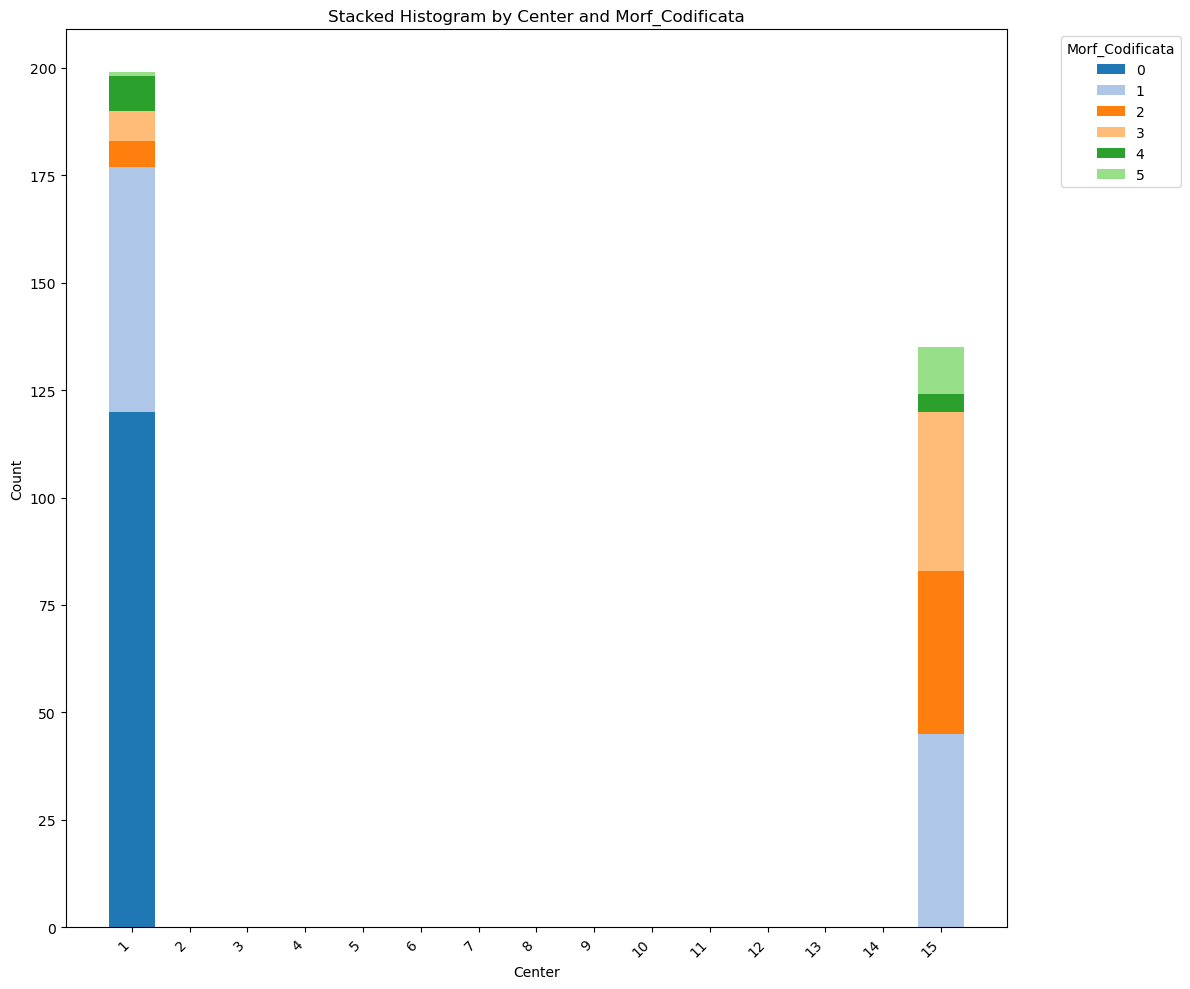

In [6]:
StackedHist(df)

In [7]:
def extract_dict(df):
    counts = df.groupby(['luogoTC_codificato', 'morf_codificata']).size().unstack(fill_value=0)
    
    all_centers = list(range(1, 16))
    all_labels = sorted(set(map(int, df['morf_codificata'])))
    
    counts = counts.reindex(index=all_centers, columns=all_labels, fill_value=0)
    
    data = {
        f"Center {center}": [int(counts.loc[center, label]) for label in all_labels]
        for center in all_centers
    }
    
    return data

data = extract_dict(df)

In [8]:
data

{'Center 1': [120, 57, 6, 7, 8, 1],
 'Center 2': [0, 0, 0, 0, 0, 0],
 'Center 3': [0, 0, 0, 0, 0, 0],
 'Center 4': [0, 0, 0, 0, 0, 0],
 'Center 5': [0, 0, 0, 0, 0, 0],
 'Center 6': [0, 0, 0, 0, 0, 0],
 'Center 7': [0, 0, 0, 0, 0, 0],
 'Center 8': [0, 0, 0, 0, 0, 0],
 'Center 9': [0, 0, 0, 0, 0, 0],
 'Center 10': [0, 0, 0, 0, 0, 0],
 'Center 11': [0, 0, 0, 0, 0, 0],
 'Center 12': [0, 0, 0, 0, 0, 0],
 'Center 13': [0, 0, 0, 0, 0, 0],
 'Center 14': [0, 0, 0, 0, 0, 0],
 'Center 15': [0, 45, 38, 37, 4, 11]}

In [9]:
!ls

Dataset  images  logging  processing.ipynb  testCalibratedModel.ipynb


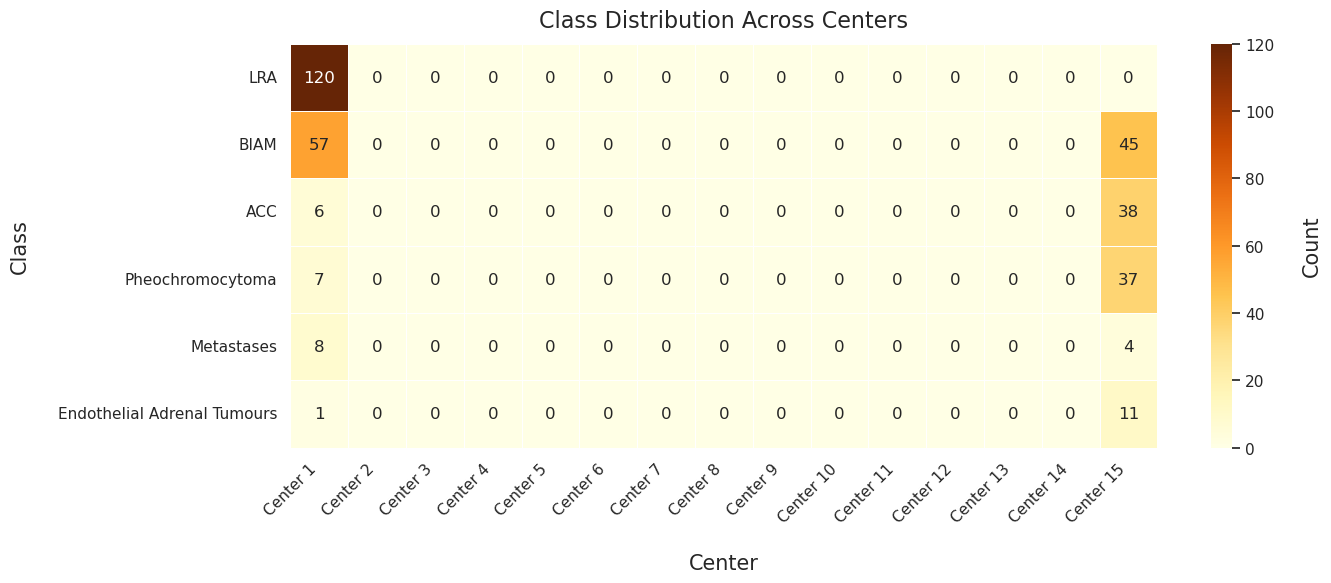

In [ ]:
import seaborn as sns

classes = ["LRA", "BIAM", "ACC", "Pheochromocytoma", "Metastases", "Endothelial Adrenal Tumours"]

df = pd.DataFrame(data, index=classes)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

ax = sns.heatmap(df, annot=True, fmt="d", cmap="YlOrBr", cbar_kws={"label": "Count"}, linewidths=0.5)

cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel("Count", labelpad=20, fontsize = 15)  # Adjust pad as needed
plt.title("Class Distribution Across Centers", fontsize=16, pad=12)
plt.xlabel("Center", fontsize=15, labelpad=20)
plt.ylabel("Class", fontsize=15, labelpad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("images/hist_distro", dpi=300)
plt.show()